# Predicting TP53 Mutation Status from Gene Expression Profiles



The Main question is: can RNA-seq expression profiles reveal whether the tumor suppressor gene **TP53** is mutated?

We answer this through two supervised learning tasks:

1. Binary classification: TP53 mutant versus TP53 wild-type.
2. Multi-class classification: broad TP53 mutation type.

The main dataset is CCLE and DepMap 

# 0. Set Up

In [55]:
from pathlib import Path
import os
import sys
import warnings

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.decomposition import PCA
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tp53_ml.config import load_config
from tp53_ml.data import align_metadata, download_depmap_file, make_tp53_labels, read_expression, read_metadata, try_download_candidates
from tp53_ml.evaluation import binary_metrics, multiclass_metrics
from tp53_ml.genes import P53_PATHWAY_GENES, TP53_TARGET_GENES
from tp53_ml.models import binary_model_specs, feature_selectors, make_pipeline, multiclass_model_specs, positive_class_scores, selected_feature_names
from tp53_ml.preprocessing import TopVarianceSelector

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

cfg = load_config("config/project.yaml")
RANDOM_STATE = cfg["project"]["random_state"]

Path("reports/figures").mkdir(parents=True, exist_ok=True)
Path("reports/tables").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("models").mkdir(parents=True, exist_ok=True)

ROOT

PosixPath('/Users/markostamenovic/Desktop/MSc CLASSES/ML Lab/TP53-MUTATIONS')

In [ ]:
import importlib as _il, sys as _sys

_pkgs = ["numpy", "pandas", "sklearn", "scipy", "matplotlib", "seaborn", "joblib"]
_rows = []
for _p in _pkgs:
    try: _rows.append({"package": _p, "version": _il.import_module(_p).__version__})
    except Exception: _rows.append({"package": _p, "version": "N/A"})
_rows.append({"package": "python", "version": _sys.version.split()[0]})
_ver_df = pd.DataFrame(_rows)
_ver_df.to_csv("reports/tables/package_versions.csv", index=False)
print("DepMap release:", cfg["depmap"]["release"])
print("Expression file:", cfg["depmap"]["expression_file"])
_ver_df

DepMap release: DepMap Public 26Q1
Expression file: OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv


,package,version
0,numpy,1.26.4
1,pandas,2.2.2
2,sklearn,1.5.1
3,scipy,1.13.1
4,matplotlib,3.9.2
5,seaborn,0.13.2
6,joblib,1.4.2
7,python,3.12.7


## Step 1: Define the Data Source

The project needs two matched data types for every sample:

- Features: gene expression values across thousands of genes.
- Labels: TP53 mutation status derived from somatic mutation calls.

We use the DepMap public release configured in `config/project.yaml`. Current DepMap releases store protein-coding expression in log-transformed TPM form.

In [57]:
raw_dir = Path(cfg["data"]["raw_dir"])
raw_dir.mkdir(parents=True, exist_ok=True)

release = cfg["depmap"]["release"]
expression_file = cfg["depmap"]["expression_file"]
mutation_candidates = cfg["depmap"]["mutation_file_candidates"]
metadata_candidates = cfg["depmap"]["metadata_file_candidates"]

expression_path = raw_dir / expression_file
mutation_path = next((raw_dir / name for name in mutation_candidates if (raw_dir / name).exists()), None)
metadata_path = next((raw_dir / name for name in metadata_candidates if (raw_dir / name).exists()), None)

print("DepMap release:", release)
print("Expression file:", expression_path)
print("Mutation file:", mutation_path)
print("Metadata file:", metadata_path)

DepMap release: DepMap Public 26Q1
Expression file: data/raw/OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv
Mutation file: data/raw/OmicsSomaticMutations.csv
Metadata file: data/raw/Model.csv


If the files are missing, run the next cell. It is safe to skip it when the paths above already exist and have realistic file sizes.

In [58]:
if not expression_path.exists() or mutation_path is None or metadata_path is None:
    expression_path = download_depmap_file(release, expression_file, raw_dir)
    mutation_path = try_download_candidates(release, mutation_candidates, raw_dir)
    metadata_path = try_download_candidates(release, metadata_candidates, raw_dir)

print("Ready to use:")
print(expression_path)
print(mutation_path)
print(metadata_path)

Ready to use:
data/raw/OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv
data/raw/OmicsSomaticMutations.csv
data/raw/Model.csv


## Step 2: Build the Matched Machine-Learning Dataset

The raw expression file contains expression values and a few DepMap metadata columns. The mutation file contains one row per variant. We need one row per sample with a single TP53 label.

For samples with multiple TP53 mutations, we assign the most severe observed consequence. This prevents a sample with both a damaging and a milder TP53 variant from being mislabeled as only the milder type.

In [59]:
X = read_expression(expression_path)
mutations = pd.read_csv(mutation_path, low_memory=False)
metadata_raw = read_metadata(metadata_path)

labels = make_tp53_labels(mutations, X.index)
metadata = align_metadata(metadata_raw, X.index)

assert list(X.index.astype(str)) == labels["sample_id"].astype(str).to_list()
assert list(X.index.astype(str)) == metadata["sample_id"].astype(str).to_list()

X.to_csv(cfg["data"]["expression_processed"], compression="gzip")
labels.to_csv(cfg["data"]["labels_processed"], index=False)
metadata.to_csv(cfg["data"]["metadata_processed"], index=False)

print(f"Matched expression matrix: {X.shape[0]} samples x {X.shape[1]} genes")
print(f"Labels table: {labels.shape}")
print(f"Metadata table: {metadata.shape}")

Matched expression matrix: 1719 samples x 19215 genes
Labels table: (1719, 4)
Metadata table: (1719, 49)


## Step 3: Inspect TP53 Label Construction

Before modelling, we check whether the binary classes and mutation-type labels are biologically plausible. TP53 is frequently mutated in cancer, so we expect many mutant samples, but not all samples should be mutant.

In [60]:
binary_balance = (
    labels["tp53_mutant"]
    .map({0: "WT", 1: "Mutant"})
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)
binary_balance["percentage"] = 100 * binary_balance["count"] / binary_balance["count"].sum()

mutation_balance = labels["mutation_type_collapsed"].value_counts().rename_axis("mutation_type").reset_index(name="count")
mutation_balance["percentage"] = 100 * mutation_balance["count"] / mutation_balance["count"].sum()

display(binary_balance)
display(mutation_balance)

,class,count,percentage
0,Mutant,997,57.998837
1,WT,722,42.001163


,mutation_type,count,percentage
0,WT,722,42.001163
1,Missense,620,36.067481
2,Other,189,10.994764
3,Nonsense,113,6.573589
4,Frameshift,58,3.374055
5,In-frame indel,9,0.523560
6,Synonymous,8,0.465387


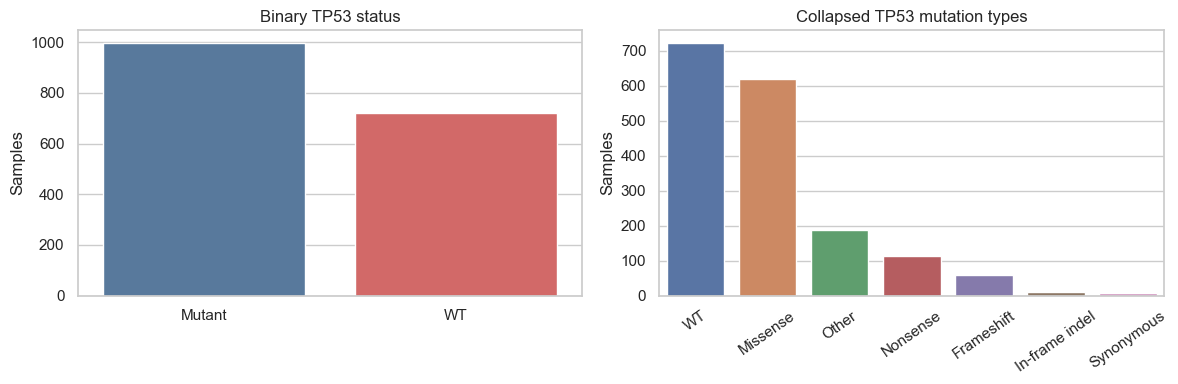

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=binary_balance, x="class", y="count", hue="class", legend=False, ax=axes[0], palette=["#4C78A8", "#E45756"])
axes[0].set_title("Binary TP53 status")
axes[0].set_xlabel("")
axes[0].set_ylabel("Samples")

sns.barplot(data=mutation_balance, x="mutation_type", y="count", hue="mutation_type", legend=False, ax=axes[1])
axes[1].set_title("Collapsed TP53 mutation types")
axes[1].set_xlabel("")
axes[1].set_ylabel("Samples")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## Step 4: Inspect Expression Data

Gene expression data is high dimensional: we have many more genes than samples. This is typical for biomedical machine learning and motivates regularization, feature filtering, and strict leakage prevention.

In [62]:
expression_summary = pd.DataFrame(
    [
        {"metric": "samples", "value": X.shape[0]},
        {"metric": "genes", "value": X.shape[1]},
        {"metric": "missing_values", "value": int(X.isna().sum().sum())},
        {"metric": "mean_expression", "value": float(X.to_numpy().mean())},
        {"metric": "median_expression", "value": float(pd.Series(X.to_numpy().ravel()).median())},
    ]
)
expression_summary

,metric,value
0,samples,1719.000000
1,genes,19215.000000
2,missing_values,0.000000
3,mean_expression,2.670069
4,median_expression,2.415231


The values are already log-transformed TPM values from DepMap, so we do not apply another log transform.

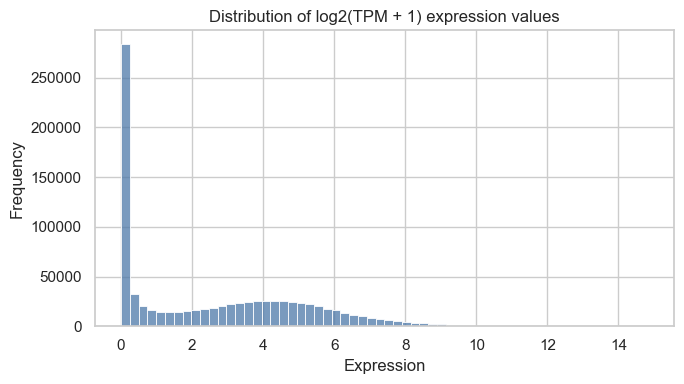

In [63]:
sampled_genes = X.sample(n=min(500, X.shape[1]), axis=1, random_state=RANDOM_STATE)
plt.figure(figsize=(7, 4))
sns.histplot(sampled_genes.to_numpy().ravel(), bins=60, color="#4C78A8")
plt.title("Distribution of log2(TPM + 1) expression values")
plt.xlabel("Expression")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Step 5: PCA Visualization

It is an exploratory tool to ask whether the dominant expression variation is related to TP53 status or to other biology, such as cancer lineage. Because PCA is fitted here only for visualization.

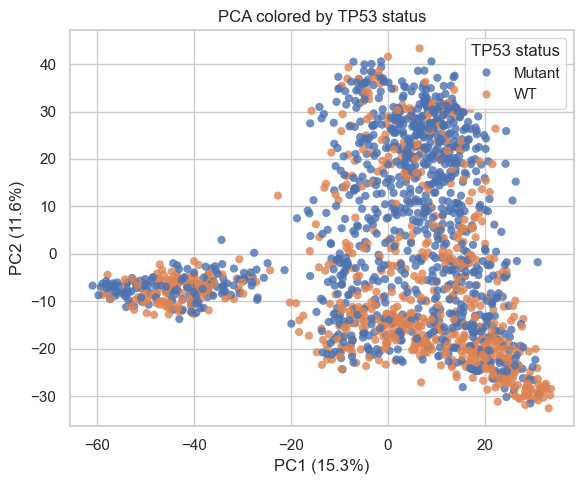

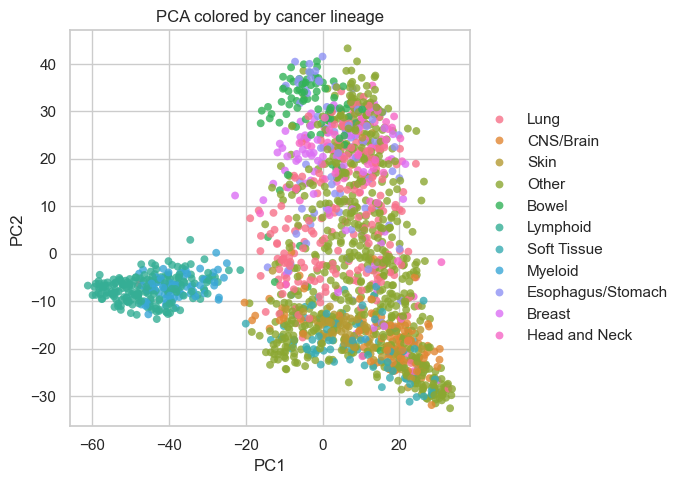

In [64]:
pca_selector = TopVarianceSelector(k=3000, min_mean_expression=cfg["features"]["min_mean_expression"])
X_pca_features = pca_selector.fit_transform(X)
X_pca_scaled = StandardScaler().fit_transform(X_pca_features)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_pca_scaled)

pca_df = pd.DataFrame(pca_coords, columns=["PC1", "PC2"])
pca_df["sample_id"] = labels["sample_id"].to_numpy()
pca_df["TP53 status"] = labels["tp53_mutant"].map({0: "WT", 1: "Mutant"}).to_numpy()

lineage_col = next((c for c in ["OncotreeLineage", "onCotreeLineage", "lineage", "primary_disease"] if c in metadata.columns), None)
if lineage_col:
    pca_df = pca_df.merge(metadata[["sample_id", lineage_col]], on="sample_id", how="left")
    top_lineages = pca_df[lineage_col].value_counts().head(10).index
    pca_df["lineage_plot"] = pca_df[lineage_col].where(pca_df[lineage_col].isin(top_lineages), "Other")

fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="TP53 status", s=35, linewidth=0, alpha=0.8, ax=ax)
ax.set_title("PCA colored by TP53 status")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.tight_layout()
plt.show()

if lineage_col:
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="lineage_plot", s=32, linewidth=0, alpha=0.8, ax=ax)
    ax.set_title("PCA colored by cancer lineage")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()

## Step 6: Train, Validation, and Test Split

We split after label creation and before supervised preprocessing. This matters because feature selection and scaling must be learned from training data only. If feature filtering used the full dataset before splitting, information from validation or test samples would leak into the model.

In [65]:
y_binary = labels["tp53_mutant"].astype(int)

X_trainval, X_test, y_trainval, y_test, labels_trainval, labels_test = train_test_split(
    X,
    y_binary,
    labels,
    test_size=cfg["split"]["test_size"],
    stratify=y_binary,
    random_state=RANDOM_STATE,
)

val_fraction = cfg["split"]["validation_size"] / (1 - cfg["split"]["test_size"])

split_summary = pd.DataFrame(
    {
        "split": ["train+val (CV)", "test"],
        "samples": [len(y_trainval), len(y_test)],
        "mutant_fraction": [y_trainval.mean(), y_test.mean()],
    }
)
split_summary

,split,samples,mutant_fraction
0,train+val (CV),1461,0.579740
1,test,258,0.581395


## Step 7: Define Feature Sets and Binary Models

We compare data-driven and biology-driven feature sets:

- Top variable genes: broad expression signal, less interpretable.
- TP53 target genes: direct biological prior, highly interpretable.
- p53 pathway genes: slightly broader biological prior including DNA damage, apoptosis, and cell-cycle genes.

Each feature selector is placed inside an sklearn pipeline so it is fitted only on the training split.

In [66]:
selectors = feature_selectors(cfg["features"]["top_variable_genes"], cfg["features"]["min_mean_expression"])
binary_models = binary_model_specs(RANDOM_STATE)

scale_models = {"logistic_l2", "elastic_net_logistic", "linear_svm", "mlp"}

print("Feature sets:", list(selectors))
print("Binary models:", list(binary_models))

Feature sets: ['top_3000_variable', 'tp53_targets', 'p53_pathway']
Binary models: ['majority', 'logistic_l2', 'elastic_net_logistic', 'linear_svm', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'mlp']


We now use **5-fold stratified cross-validation** on the combined train + validation
pool to rank all model/feature-set combinations. CV gives a more stable ranking than a
single held-out fold and uses all available labelled training data. The test set remains
completely untouched.

In [67]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

binary_cv_rows = []
for feature_name, selector in selectors.items():
    for model_name, model in binary_models.items():
        if model_name in {"hist_gradient_boosting", "mlp"} and not feature_name.startswith("top_"):
            continue
        pipe = make_pipeline(selector, model, scale=model_name in scale_models)
        _cv_res = cross_validate(pipe, X_trainval, y_trainval, cv=cv,
                                 scoring=["roc_auc", "balanced_accuracy"], n_jobs=1)
        binary_cv_rows.append({
            "roc_auc_mean":          _cv_res["test_roc_auc"].mean(),
            "roc_auc_std":           _cv_res["test_roc_auc"].std(),
            "balanced_accuracy_mean": _cv_res["test_balanced_accuracy"].mean(),
            "balanced_accuracy_std":  _cv_res["test_balanced_accuracy"].std(),
            "feature_set": feature_name,
            "model":       model_name,
        })

binary_cv = pd.DataFrame(binary_cv_rows).sort_values("roc_auc_mean", ascending=False)
binary_cv.to_csv("reports/tables/binary_cv_performance.csv", index=False)

display_cv = binary_cv.copy()
display_cv["roc_auc (mean ± std)"] = display_cv.apply(
    lambda r: f"{r['roc_auc_mean']:.4f} ± {r['roc_auc_std']:.4f}", axis=1)
display_cv["bal_acc (mean ± std)"] = display_cv.apply(
    lambda r: f"{r['balanced_accuracy_mean']:.4f} ± {r['balanced_accuracy_std']:.4f}", axis=1)
display_cv[["feature_set", "model", "roc_auc (mean ± std)", "bal_acc (mean ± std)"]].head(14)

,feature_set,model,roc_auc (mean ± std),bal_acc (mean ± std)
16,p53_pathway,elastic_net_logistic,0.9099 ± 0.0173,0.8488 ± 0.0270
6,top_3000_variable,hist_gradient_boosting,0.9094 ± 0.0338,0.8490 ± 0.0225
17,p53_pathway,linear_svm,0.9084 ± 0.0198,0.8528 ± 0.0247
18,p53_pathway,random_forest,0.9079 ± 0.0236,0.8492 ± 0.0166
15,p53_pathway,logistic_l2,0.9078 ± 0.0196,0.8469 ± 0.0288
19,p53_pathway,extra_trees,0.9065 ± 0.0260,0.8457 ± 0.0178
10,tp53_targets,elastic_net_logistic,0.9054 ± 0.0192,0.8460 ± 0.0191
9,tp53_targets,logistic_l2,0.9052 ± 0.0193,0.8455 ± 0.0200
11,tp53_targets,linear_svm,0.9048 ± 0.0203,0.8446 ± 0.0231
12,tp53_targets,random_forest,0.9044 ± 0.0246,0.8468 ± 0.0294


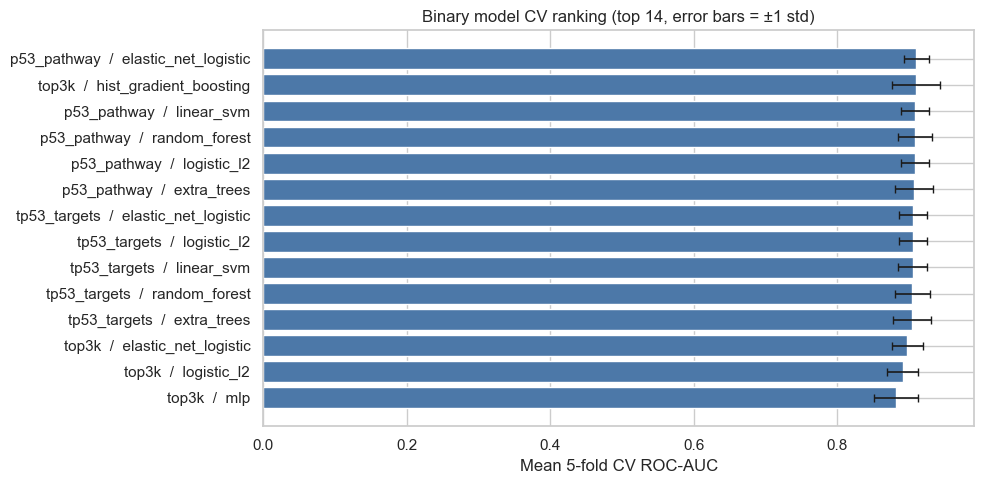

In [68]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = binary_cv.head(14).copy()
plot_df["label"] = (
    plot_df["feature_set"].str.replace("top_3000_variable", "top3k", regex=False)
    + "  /  " + plot_df["model"]
)
ax.barh(
    plot_df["label"].iloc[::-1],
    plot_df["roc_auc_mean"].iloc[::-1],
    xerr=plot_df["roc_auc_std"].iloc[::-1],
    color="#4C78A8", edgecolor="white",
    error_kw={"elinewidth": 1.2, "capsize": 3},
)
ax.set_xlabel("Mean 5-fold CV ROC-AUC")
ax.set_title("Binary model CV ranking (top 14, error bars = ±1 std)")
plt.tight_layout()
plt.savefig("reports/figures/binary_cv_ranking.png", dpi=180)
plt.show()

### Step 7b: Hyperparameter Tuning

`RandomizedSearchCV` refines the top-ranked model/feature combination using the same
5-fold CV strategy. This searches over a compact grid of regularisation strengths and
tree parameters without ever touching the held-out test set.

In [69]:
from sklearn.model_selection import RandomizedSearchCV

best_cv_row       = binary_cv.iloc[0]
best_cv_feature   = best_cv_row["feature_set"]
best_cv_model_nm  = best_cv_row["model"]

param_grids = {
    "random_forest": {
        "model__n_estimators":   [200, 400, 600, 800],
        "model__max_features":   ["sqrt", "log2", 0.2, 0.3],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_depth":      [None, 10, 20, 30],
    },
    "extra_trees": {
        "model__n_estimators":   [200, 400, 600],
        "model__max_features":   ["sqrt", "log2", 0.2],
        "model__min_samples_leaf": [1, 2, 4],
    },
    "elastic_net_logistic": {
        "model__C":       [0.01, 0.05, 0.1, 0.5, 1.0, 5.0],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    },
    "logistic_l2": {
        "model__C": [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    },
    "hist_gradient_boosting": {
        "model__learning_rate":    [0.01, 0.05, 0.1, 0.2],
        "model__max_iter":         [100, 200, 400],
        "model__max_leaf_nodes":   [15, 31, 63],
        "model__l2_regularization": [0.0, 0.1, 0.5],
    },
    "mlp": {
        "model__hidden_layer_sizes": [(128,), (256, 64), (512, 128, 32), (256, 128, 64)],
        "model__alpha":              [0.0001, 0.001, 0.01],
        "model__learning_rate_init": [0.001, 0.005, 0.01],
    },
}

base_pipe = make_pipeline(
    selectors[best_cv_feature], binary_models[best_cv_model_nm],
    scale=best_cv_model_nm in scale_models,
)

param_grid = param_grids.get(best_cv_model_nm, {})
if param_grid:
    search = RandomizedSearchCV(
        base_pipe, param_grid, n_iter=25, cv=cv,
        scoring="roc_auc", n_jobs=1, random_state=RANDOM_STATE, refit=True, verbose=0,
    )
    search.fit(X_trainval, y_trainval)
    best_binary_tuned = search.best_estimator_
    print(f"Model:          {best_cv_model_nm} / {best_cv_feature}")
    print(f"CV AUC before:  {best_cv_row['roc_auc_mean']:.4f} ± {best_cv_row['roc_auc_std']:.4f}")
    print(f"CV AUC after:   {search.best_score_:.4f}")
    print(f"Best params:    {search.best_params_}")
else:
    base_pipe.fit(X_trainval, y_trainval)
    best_binary_tuned = base_pipe
    print(f"No parameter grid for '{best_cv_model_nm}' — using default settings.")

Model:          elastic_net_logistic / p53_pathway
CV AUC before:  0.9099 ± 0.0173
CV AUC after:   0.9108
Best params:    {'model__l1_ratio': 0.1, 'model__C': 0.05}


## Step 8: Evaluate the Selected Binary Model on the Test Set

The best model is selected by 5-fold CV ROC-AUC and refined by `RandomizedSearchCV`
(Step 7b). After choosing the model we evaluate **exactly once** on the held-out test
set — no re-tuning after peeking at test results.

In [70]:
best_binary_row  = binary_cv.iloc[0]
best_feature_set = best_binary_row["feature_set"]
best_model_name  = best_binary_row["model"]

# The tuned model (best_binary_tuned) was already fitted on X_trainval in Step 7b.
best_binary_model = best_binary_tuned

y_test_pred  = best_binary_model.predict(X_test)
y_test_score = positive_class_scores(best_binary_model, X_test)

binary_test = pd.DataFrame([{
    **binary_metrics(y_test, y_test_pred, y_test_score),
    "feature_set": best_feature_set,
    "model":       best_model_name,
}])
binary_test.to_csv("reports/tables/binary_test_performance.csv", index=False)
joblib.dump(best_binary_model, "models/best_binary_model.joblib")

display(best_binary_row.to_frame("best_cv_model"))
display(binary_test)

,best_cv_model
roc_auc_mean,0.909858
roc_auc_std,0.017326
balanced_accuracy_mean,0.848823
balanced_accuracy_std,0.026961
feature_set,p53_pathway
model,elastic_net_logistic


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,feature_set,model
0,0.844961,0.835556,0.848101,0.893333,0.87013,0.907099,0.926426,p53_pathway,elastic_net_logistic


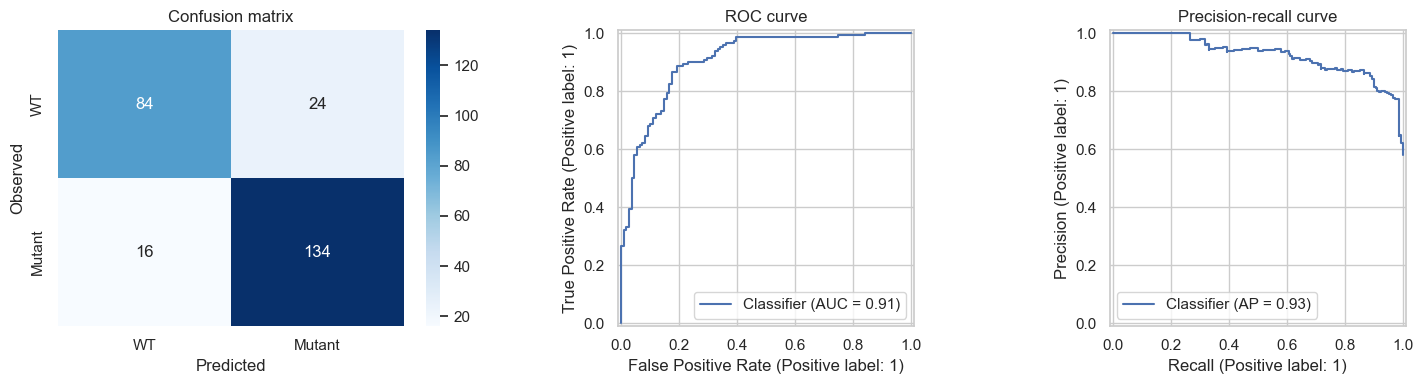

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["WT", "Mutant"], yticklabels=["WT", "Mutant"], ax=axes[0])
axes[0].set_title("Confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Observed")

RocCurveDisplay.from_predictions(y_test, y_test_score, ax=axes[1])
axes[1].set_title("ROC curve")

PrecisionRecallDisplay.from_predictions(y_test, y_test_score, ax=axes[2])
axes[2].set_title("Precision-recall curve")

plt.tight_layout()
plt.show()

### Step 8b: Bootstrap Confidence Intervals

A single point estimate on a 258-sample test set has non-trivial sampling variance.
Non-parametric bootstrap (n = 1 000) provides 95 % CIs for ROC-AUC and F1 without
distributional assumptions.

Binary test set — 95 % bootstrap CIs  (n_boot = 1 000)
  ROC-AUC : 0.9071  [0.8653, 0.9402]
  F1      : 0.8701  [0.8304,  0.9073]


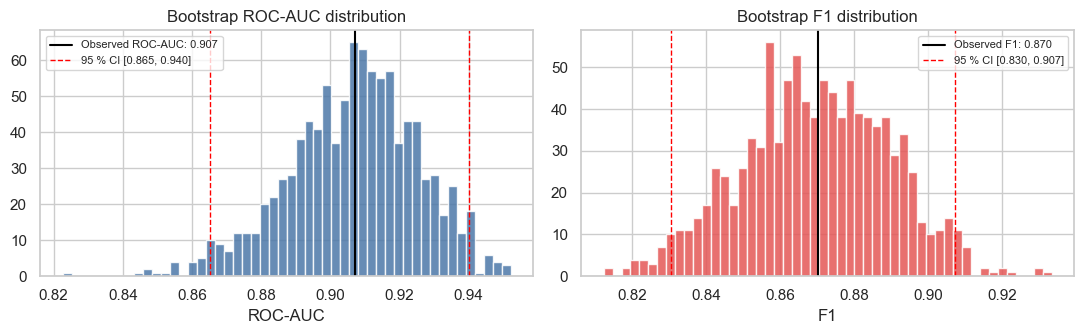

In [72]:
from sklearn.metrics import roc_auc_score as _boot_roc, f1_score as _boot_f1

rng        = np.random.RandomState(RANDOM_STATE)
n_boot     = 1000
boot_auc, boot_f1 = [], []
y_test_arr = np.asarray(y_test)
n_test     = len(y_test_arr)

for _ in range(n_boot):
    idx = rng.randint(0, n_test, n_test)
    boot_auc.append(_boot_roc(y_test_arr[idx], y_test_score[idx]))
    boot_f1.append( _boot_f1( y_test_arr[idx], y_test_pred[idx],  zero_division=0))

ci_auc = np.percentile(boot_auc, [2.5, 97.5])
ci_f1  = np.percentile(boot_f1,  [2.5, 97.5])

obs_auc = float(binary_test["roc_auc"].iloc[0])
obs_f1  = float(binary_test["f1"].iloc[0])
print("Binary test set — 95 % bootstrap CIs  (n_boot = 1 000)")
print(f"  ROC-AUC : {obs_auc:.4f}  [{ci_auc[0]:.4f}, {ci_auc[1]:.4f}]")
print(f"  F1      : {obs_f1:.4f}  [{ci_f1[0]:.4f},  {ci_f1[1]:.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, vals, ci, obs, label, color in [
    (axes[0], boot_auc, ci_auc, obs_auc, "ROC-AUC", "#4C78A8"),
    (axes[1], boot_f1,  ci_f1,  obs_f1,  "F1",      "#E45756"),
]:
    ax.hist(vals, bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(obs,   color="black", linewidth=1.5, label=f"Observed {label}: {obs:.3f}")
    ax.axvline(ci[0], color="red",   linestyle="--", linewidth=1,
               label=f"95 % CI [{ci[0]:.3f}, {ci[1]:.3f}]")
    ax.axvline(ci[1], color="red",   linestyle="--", linewidth=1)
    ax.set_title(f"Bootstrap {label} distribution")
    ax.set_xlabel(label)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("reports/figures/binary_bootstrap_ci.png", dpi=180)
plt.show()

### Step 8c: Cancer-Lineage Confounding Check

TP53 mutation frequency varies strongly across cancer lineages, and the PCA (Step 5)
showed that lineage drives a large fraction of global expression variance.  We therefore
evaluate the best binary model **within each lineage** on the test set.  A model that
can only separate lineages — rather than TP53 status inside a lineage — would score
near chance here even if its overall AUC is high.

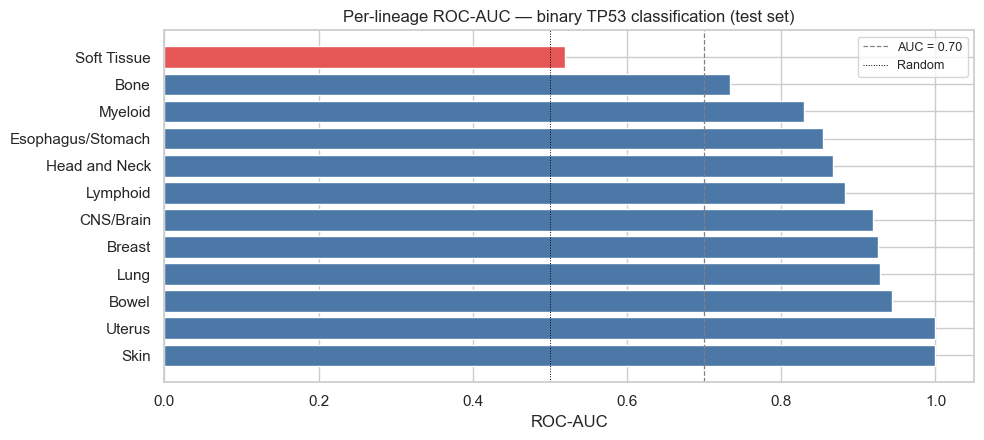

,lineage,n,mutant_frac,balanced_accuracy,roc_auc
9,Skin,18,0.33,0.750,1.000
11,Uterus,8,0.62,1.000,1.000
1,Bowel,11,0.82,0.500,0.944
6,Lung,29,0.79,0.917,0.928
2,Breast,13,0.62,0.838,0.925
3,CNS/Brain,20,0.45,0.864,0.919
7,Lymphoid,32,0.66,0.816,0.883
5,Head and Neck,13,0.77,0.617,0.867
4,Esophagus/Stomach,16,0.75,0.667,0.854
8,Myeloid,12,0.58,0.900,0.829


In [73]:
lineage_col = next(
    (c for c in ["OncotreeLineage", "onCotreeLineage", "lineage", "primary_disease"]
     if c in metadata.columns),
    None,
)

if lineage_col:
    from sklearn.metrics import balanced_accuracy_score as _bac, roc_auc_score as _rauc

    test_meta = metadata.set_index("sample_id").reindex(X_test.index).reset_index()
    lin_df = pd.DataFrame({
        "sample_id":   list(X_test.index),
        "tp53_mutant": y_test.values,
        "predicted":   y_test_pred,
        "score":       y_test_score,
        "lineage":     test_meta[lineage_col].values,
    })

    lin_rows = []
    for lin, grp in lin_df.dropna(subset=["lineage"]).groupby("lineage"):
        if len(grp) < 8 or grp["tp53_mutant"].nunique() < 2:
            continue
        lin_rows.append({
            "lineage":            lin,
            "n":                  len(grp),
            "mutant_frac":        round(grp["tp53_mutant"].mean(), 2),
            "balanced_accuracy":  round(_bac( grp["tp53_mutant"], grp["predicted"]), 3),
            "roc_auc":            round(_rauc(grp["tp53_mutant"], grp["score"]),     3),
        })

    lineage_perf = pd.DataFrame(lin_rows).sort_values("roc_auc", ascending=False)
    lineage_perf.to_csv("reports/tables/binary_per_lineage_performance.csv", index=False)

    fig, ax = plt.subplots(figsize=(10, max(4, len(lineage_perf) * 0.38)))
    bar_colors = ["#E45756" if v < 0.7 else "#4C78A8" for v in lineage_perf["roc_auc"]]
    ax.barh(lineage_perf["lineage"], lineage_perf["roc_auc"], color=bar_colors)
    ax.axvline(0.7,  color="grey",  linestyle="--", linewidth=0.9, label="AUC = 0.70")
    ax.axvline(0.5,  color="black", linestyle=":",  linewidth=0.7, label="Random")
    ax.set_xlabel("ROC-AUC")
    ax.set_title("Per-lineage ROC-AUC — binary TP53 classification (test set)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig("reports/figures/binary_per_lineage_auc.png", dpi=180)
    plt.show()
    display(lineage_perf)
else:
    print("No lineage column found in metadata — skipping per-lineage analysis.")

### Step 8d: Lineage-Only Baseline

Different cancer lineages have distinct TP53 mutation frequencies and distinct
expression profiles.  To determine whether the expression model captures TP53 biology
*beyond* lineage composition, we train a logistic regression using **only one-hot
encoded cancer lineage** as input and compare it to the full expression model.

The table below shows majority-class baseline, lineage-only baseline, and the best
expression model side by side.  The expression model is evidence for a genuine
TP53-associated transcriptional signal only if it **clearly outperforms** the
lineage-only baseline.  The reported Δ ROC-AUC quantifies the gain; a Δ < 0.05
should be flagged as limited evidence for biology beyond lineage composition.

In [74]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression as _LinLR
from sklearn.dummy import DummyClassifier as _Dummy

_lin_col = next(
    (c for c in ["OncotreeLineage","onCotreeLineage","lineage","primary_disease"]
     if c in metadata.columns), None,
)

if _lin_col:
    _meta_idx = metadata.set_index("sample_id")
    _lin_tv   = _meta_idx.reindex(X_trainval.index)[_lin_col].fillna("Unknown")
    _lin_te   = _meta_idx.reindex(X_test.index)[_lin_col].fillna("Unknown")

    _ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    _X_lin_tv = _ohe.fit_transform(_lin_tv.values.reshape(-1,1))
    _X_lin_te = _ohe.transform(_lin_te.values.reshape(-1,1))

    _lin_clf = _LinLR(C=1.0, class_weight="balanced", max_iter=2000,
                      random_state=RANDOM_STATE, solver="lbfgs")
    _lin_clf.fit(_X_lin_tv, y_trainval)
    _y_lin_pred  = _lin_clf.predict(_X_lin_te)
    _y_lin_score = _lin_clf.predict_proba(_X_lin_te)[:,1]

    _dummy = _Dummy(strategy="most_frequent")
    _dummy.fit(X_trainval, y_trainval)
    _y_dum_pred  = _dummy.predict(X_test)
    _y_dum_score = _dummy.predict_proba(X_test)[:,1]

    _expr_m = {k: float(binary_test.loc[0,k])
               for k in ["roc_auc","pr_auc","f1","balanced_accuracy","accuracy"]}

    baseline_comparison = pd.DataFrame([
        {"model": "Majority-class baseline",
         **binary_metrics(y_test, _y_dum_pred, _y_dum_score)},
        {"model": f"Lineage-only ({_lin_col})",
         **binary_metrics(y_test, _y_lin_pred, _y_lin_score)},
        {"model": f"Expression ({best_model_name} / {best_feature_set})",
         **_expr_m},
    ])[["model","roc_auc","pr_auc","f1","balanced_accuracy","accuracy"]]

    baseline_comparison.to_csv("reports/tables/baseline_comparison.csv", index=False)
    display(baseline_comparison.round(4))

    _delta = float(binary_test.loc[0,"roc_auc"]) - binary_metrics(
        y_test, _y_lin_pred, _y_lin_score)["roc_auc"]
    print(f"\nExpression model gains {_delta:+.4f} ROC-AUC over the lineage-only baseline.")
    if _delta > 0.05:
        print("→ Substantial gain: the model captures TP53 biology beyond lineage composition.")
    elif _delta > 0.01:
        print("→ Moderate gain: lineage confounding is partially mitigated but remains a concern.")
    else:
        print("→ Minimal gain: lineage confounding is a major limitation.")
else:
    print("No lineage column found — skipping lineage-only baseline.")

,model,roc_auc,pr_auc,f1,balanced_accuracy,accuracy
0,Majority-class baseline,0.5000,0.5814,0.7353,0.5000,0.5814
1,Lineage-only (OncotreeLineage),0.7055,0.7254,0.7110,0.6530,0.6628
2,Expression (elastic_net_logistic / p53_pathway),0.9071,0.9264,0.8701,0.8356,0.8450



Expression model gains +0.2016 ROC-AUC over the lineage-only baseline.
→ Substantial gain: the model captures TP53 biology beyond lineage composition.


### Step 8e: Sensitivity Analysis — Excluding TP53 Expression

If the model relies primarily on TP53 transcript levels rather than downstream pathway
effects, its biological interpretation is weaker.  We rerun the best feature sets after
removing TP53 from the gene lists and compare 5-fold CV ROC-AUC.

**Interpreting the Δ column:**  a small drop (< 0.02) when TP53 is removed supports
the interpretation that the model captures *broader downstream pathway dysregulation*,
not just TP53 transcript abundance.  A large drop (> 0.05) indicates that TP53
expression is a primary driver and the downstream-only signal is weaker.

,feature_set,model,includes_TP53,roc_auc (mean ± std)
0,p53_pathway (with TP53),logistic_l2,True,0.9078 ± 0.0196
1,p53_pathway (with TP53),elastic_net_logistic,True,0.9099 ± 0.0173
2,p53_pathway (with TP53),random_forest,True,0.9079 ± 0.0236
3,p53_pathway (with TP53),extra_trees,True,0.9065 ± 0.0260
4,p53_pathway (excl. TP53),logistic_l2,False,0.8976 ± 0.0278
5,p53_pathway (excl. TP53),elastic_net_logistic,False,0.8998 ± 0.0262
6,p53_pathway (excl. TP53),random_forest,False,0.8958 ± 0.0292
7,p53_pathway (excl. TP53),extra_trees,False,0.9034 ± 0.0286
8,tp53_targets (with TP53),logistic_l2,True,0.9052 ± 0.0193
9,tp53_targets (with TP53),elastic_net_logistic,True,0.9054 ± 0.0192


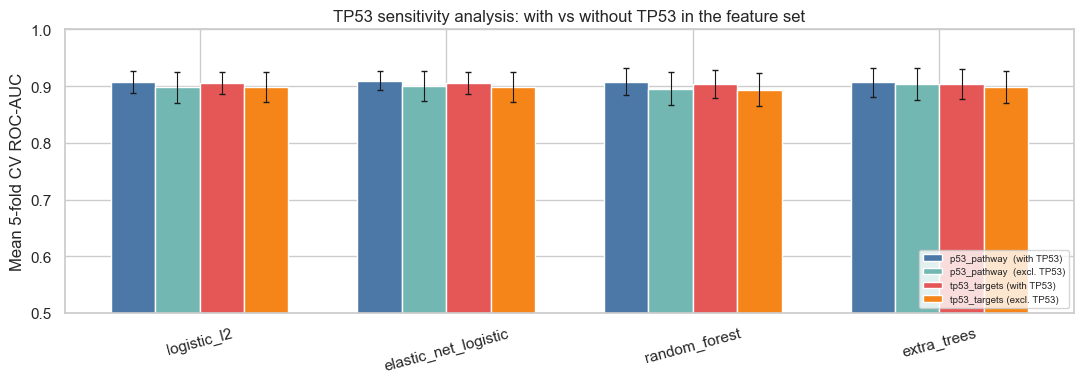

In [75]:
from sklearn.model_selection import cross_val_score

from tp53_ml.preprocessing import GeneSetSelector as _GSS

_sens_selectors = {
    "p53_pathway  (with TP53)":  selectors["p53_pathway"],
    "p53_pathway  (excl. TP53)": _GSS([g for g in P53_PATHWAY_GENES  if g != "TP53"]),
    "tp53_targets (with TP53)":  selectors["tp53_targets"],
    "tp53_targets (excl. TP53)": _GSS([g for g in TP53_TARGET_GENES if g != "TP53"]),
}
_sens_model_names = {"logistic_l2","elastic_net_logistic","random_forest","extra_trees"}
_sens_models = {k:v for k,v in binary_models.items() if k in _sens_model_names}

_sens_rows = []
for _fn, _sel in _sens_selectors.items():
    for _mn, _mod in _sens_models.items():
        _pipe = make_pipeline(_sel, _mod, scale=_mn in scale_models)
        _cv_a = cross_val_score(_pipe, X_trainval, y_trainval, cv=cv,
                                scoring="roc_auc", n_jobs=1)
        _sens_rows.append({
            "feature_set":   _fn,
            "model":         _mn,
            "includes_TP53": "excl." not in _fn,
            "roc_auc_mean":  _cv_a.mean(),
            "roc_auc_std":   _cv_a.std(),
        })

sens_df = pd.DataFrame(_sens_rows)
sens_df.to_csv("reports/tables/tp53_exclusion_sensitivity.csv", index=False)

_sd = sens_df.copy()
_sd["roc_auc (mean ± std)"] = _sd.apply(
    lambda r: f"{r['roc_auc_mean']:.4f} ± {r['roc_auc_std']:.4f}", axis=1)
display(_sd[["feature_set","model","includes_TP53","roc_auc (mean ± std)"]])

# Bar chart: with vs without TP53
_feat_order = list(dict.fromkeys(_sd["feature_set"]))
_mod_order  = list(dict.fromkeys(_sd["model"]))
_x = np.arange(len(_mod_order))
_w = 0.18
_palette = ["#4C78A8","#72B7B2","#E45756","#F58518"]

fig, ax = plt.subplots(figsize=(11,4))
for _i, _fn in enumerate(_feat_order):
    _g = sens_df[sens_df["feature_set"]==_fn].set_index("model").reindex(_mod_order)
    ax.bar(_x + _i*_w - (len(_feat_order)-1)*_w/2,
           _g["roc_auc_mean"], _w,
           yerr=_g["roc_auc_std"], capsize=2,
           color=_palette[_i%4], label=_fn, edgecolor="white",
           error_kw={"elinewidth":0.8})

ax.set_xticks(_x); ax.set_xticklabels(_mod_order, rotation=15)
ax.set_ylabel("Mean 5-fold CV ROC-AUC"); ax.set_ylim(0.5,1.0)
ax.set_title("TP53 sensitivity analysis: with vs without TP53 in the feature set")
ax.legend(fontsize=7, loc="lower right")
plt.tight_layout()
plt.savefig("reports/figures/tp53_sensitivity_analysis.png", dpi=180)
plt.show()

## Step 9: Mutation-Type Classification

The second task distinguishes broad TP53 mutation classes (WT, Hotspot Missense,
Other Missense, Truncating, Other).  This task is harder than binary classification
for several compounding reasons.

### Why mutation-type prediction is harder

- **Mutation consequence ≠ functional effect.**  A missense variant at a hotspot
  residue may be a dominant-negative, gain-of-function, or partial loss-of-function
  depending on the specific amino acid substitution and the cellular context.
- **Class imbalance.**  Hotspot missense and in-frame indels are rare relative to WT
  and other missense, making per-class recall hard to optimise.
- **Overlapping expression states.**  Two missense mutations at different sites can
  produce qualitatively different transcriptional programmes, yet both appear in the
  same class label.
- **Zygosity and copy number.**  A heterozygous missense mutation alongside a WT allele
  produces a different expression signature than a homozygous or hemizygous event.
- **Co-occurring alterations.**  Other tumour-suppressor losses or oncogene activations
  modulate the expression downstream of TP53 independently of TP53 mutation type.

**Primary metrics are macro F1 and balanced accuracy.**  Overall accuracy is not
reported as the main metric because it is dominated by the large WT and Other Missense
classes.  Per-class F1 and a row-normalised confusion matrix are provided to show
where the model succeeds and where it fails.

### Hotspot Mutation Annotation

We distinguish **hotspot missense** mutations from other missense mutations, and collapse
Nonsense + Frameshift into a single **Truncating** category.

In [76]:
from tp53_ml.genes import TP53_HOTSPOT_RESIDUES

_protein_col = next(
    (c for c in ["ProteinChange","HGVSp_Short","Protein_Change","AAChange"]
     if c in mutations.columns), None,
)
_gene_col_m   = next(c for c in ["HugoSymbol","Hugo_Symbol"]   if c in mutations.columns)
_sample_col_m = next(c for c in ["ModelID","Model_ID","DepMap_ID"] if c in mutations.columns)

if _protein_col:
    _tp53_m = mutations[mutations[_gene_col_m].astype(str).str.upper()=="TP53"].copy()
    if "IsDefaultEntryForModel" in _tp53_m.columns:
        _tp53_m = _tp53_m[_tp53_m["IsDefaultEntryForModel"].astype(str).str.lower()=="yes"]
    _tp53_m["_res"] = _tp53_m[_protein_col].astype(str).str.extract(r'p\.([A-Z]\d+)', expand=False)
    _hotspot_samples = set(
        _tp53_m.loc[_tp53_m["_res"].isin(TP53_HOTSPOT_RESIDUES), _sample_col_m].astype(str))
    print(f"Hotspot missense samples ({', '.join(sorted(TP53_HOTSPOT_RESIDUES))}): "
          f"{len(_hotspot_samples)}")
else:
    _hotspot_samples = set()
    print("No protein-change column — hotspot and other missense will be merged.")

def _hotspot_type(row):
    mc = row["mutation_type_collapsed"]
    if mc == "WT":                return "WT"
    if mc == "Missense":
        return ("Hotspot Missense" if row["sample_id"] in _hotspot_samples
                else "Other Missense")
    if mc in ("Nonsense","Frameshift"): return "Truncating"
    if mc == "In-frame indel":    return "In-frame indel"
    return "Other"

labels["mutation_type_hotspot"] = labels.apply(_hotspot_type, axis=1)
print("\nEnriched mutation type distribution:")
print(labels["mutation_type_hotspot"].value_counts().to_string())

Hotspot missense samples (G245, R175, R248, R249, R273, R282): 311

Enriched mutation type distribution:
mutation_type_hotspot
WT                  722
Other Missense      376
Hotspot Missense    244
Other               197
Truncating          171
In-frame indel        9


In [77]:
# Use hotspot-enriched labels if available, else fall back to collapsed types
_label_col = ("mutation_type_hotspot" if "mutation_type_hotspot" in labels.columns
              else "mutation_type_collapsed")
y_type_raw = labels[_label_col].astype(str)
type_counts = y_type_raw.value_counts()
keep_type   = y_type_raw.isin(type_counts[type_counts >= 10].index)

X_type = X.loc[keep_type.to_numpy()]
y_type = y_type_raw.loc[keep_type].reset_index(drop=True)

type_counts_kept = y_type.value_counts().rename_axis("mutation_type").reset_index(name="count")
type_counts_kept

,mutation_type,count
0,WT,722
1,Other Missense,376
2,Hotspot Missense,244
3,Other,197
4,Truncating,171


In [78]:
X_type_trainval, X_type_test, y_type_trainval, y_type_test = train_test_split(
    X_type, y_type,
    test_size=cfg["split"]["test_size"],
    stratify=y_type,
    random_state=RANDOM_STATE,
)

X_type_train, X_type_val, y_type_train, y_type_val = train_test_split(
    X_type_trainval, y_type_trainval,
    test_size=val_fraction,
    stratify=y_type_trainval,
    random_state=RANDOM_STATE,
)

_mc_scale_models = {"logistic_l2", "elastic_net_logistic", "linear_svm", "mlp"}

multiclass_models = multiclass_model_specs(RANDOM_STATE)
multiclass_rows   = []
for feature_name, selector in selectors.items():
    for model_name, model in multiclass_models.items():
        if model_name in {"hist_gradient_boosting", "mlp"} and not feature_name.startswith("top_"):
            continue
        pipe = make_pipeline(selector, model, scale=model_name in _mc_scale_models)
        pipe.fit(X_type_train, y_type_train)
        pred = pipe.predict(X_type_val)
        row  = multiclass_metrics(y_type_val, pred)
        row.update({"feature_set": feature_name, "model": model_name})
        multiclass_rows.append(row)

multiclass_validation = pd.DataFrame(multiclass_rows).sort_values(
    ["macro_f1", "balanced_accuracy", "weighted_f1"], ascending=False
)
multiclass_validation.to_csv("reports/tables/multiclass_validation_performance.csv", index=False)
multiclass_validation.head(12)

,accuracy,balanced_accuracy,macro_f1,weighted_f1,feature_set,model
13,0.673152,0.553377,0.554957,0.657504,tp53_targets,extra_trees
19,0.677043,0.549257,0.554144,0.656196,p53_pathway,extra_trees
12,0.653696,0.533491,0.530887,0.636067,tp53_targets,random_forest
17,0.607004,0.519565,0.497495,0.601263,p53_pathway,linear_svm
10,0.591440,0.523623,0.493811,0.590205,tp53_targets,elastic_net_logistic
18,0.638132,0.493504,0.481371,0.605619,p53_pathway,random_forest
16,0.579767,0.498221,0.478690,0.585181,p53_pathway,elastic_net_logistic
9,0.571984,0.503284,0.478432,0.573177,tp53_targets,logistic_l2
11,0.599222,0.500160,0.477790,0.585394,tp53_targets,linear_svm
15,0.568093,0.482801,0.462717,0.571489,p53_pathway,logistic_l2


,best_validation_model
accuracy,0.673152
balanced_accuracy,0.553377
macro_f1,0.554957
weighted_f1,0.657504
feature_set,tp53_targets
model,extra_trees


,accuracy,balanced_accuracy,macro_f1,weighted_f1,feature_set,model
0,0.614786,0.482829,0.477145,0.598329,tp53_targets,extra_trees


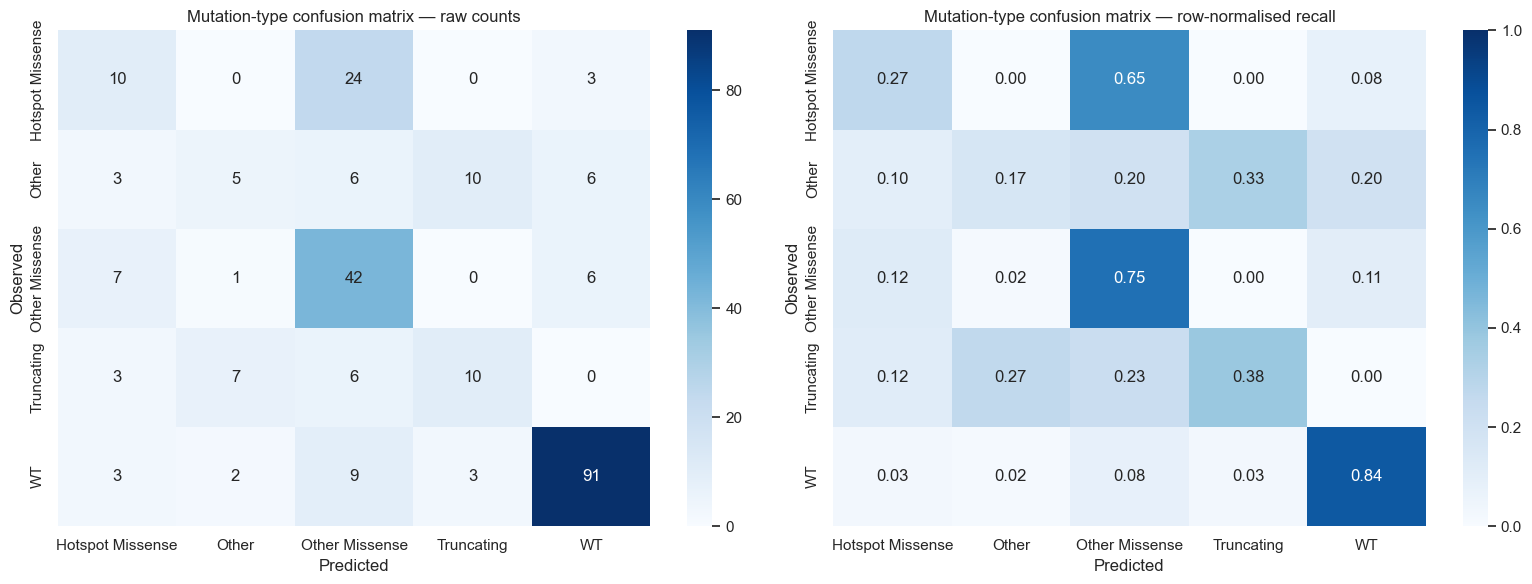


Per-class metrics (primary: macro F1 and balanced accuracy):


,precision,recall,f1-score,support
Hotspot Missense,0.385,0.270,0.317,37.0
Other,0.333,0.167,0.222,30.0
Other Missense,0.483,0.750,0.587,56.0
Truncating,0.435,0.385,0.408,26.0
WT,0.858,0.843,0.850,108.0


In [79]:
best_type_row = multiclass_validation.iloc[0]
best_type_model = make_pipeline(
    selectors[best_type_row["feature_set"]],
    multiclass_models[best_type_row["model"]],
    scale=best_type_row["model"] in _mc_scale_models,
)
best_type_model.fit(X_type_trainval, y_type_trainval)
y_type_pred = best_type_model.predict(X_type_test)

multiclass_test = pd.DataFrame([{
    **multiclass_metrics(y_type_test, y_type_pred),
    "feature_set": best_type_row["feature_set"],
    "model":       best_type_row["model"],
}])
multiclass_test.to_csv("reports/tables/multiclass_test_performance.csv", index=False)
joblib.dump(best_type_model, "models/best_multiclass_model.joblib")

display(best_type_row.to_frame("best_validation_model"))
display(multiclass_test)

ordered_type_labels = sorted(y_type.unique())
cm_raw  = confusion_matrix(y_type_test, y_type_pred, labels=ordered_type_labels)
cm_norm = confusion_matrix(y_type_test, y_type_pred, labels=ordered_type_labels, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_raw,  annot=True, fmt="d",    cmap="Blues",
            xticklabels=ordered_type_labels, yticklabels=ordered_type_labels, ax=axes[0])
axes[0].set_title("Mutation-type confusion matrix — raw counts")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Observed")

sns.heatmap(cm_norm, annot=True, fmt=".2f",  cmap="Blues", vmin=0, vmax=1,
            xticklabels=ordered_type_labels, yticklabels=ordered_type_labels, ax=axes[1])
axes[1].set_title("Mutation-type confusion matrix — row-normalised recall")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Observed")

plt.tight_layout()
plt.savefig("reports/figures/multiclass_confusion_matrices.png", dpi=180)
plt.show()
from sklearn.metrics import classification_report
_report_dict = classification_report(y_type_test, y_type_pred, output_dict=True)
_per_class = (
    pd.DataFrame(_report_dict).T
    .loc[[c for c in sorted(y_type.unique()) if c in _report_dict]]
    [["precision","recall","f1-score","support"]]
    .round(3)
)
_per_class.to_csv("reports/tables/multiclass_per_class_metrics.csv")
print("\nPer-class metrics (primary: macro F1 and balanced accuracy):")
display(_per_class)

### Step 9b: Multiclass Model Feature Interpretation and Per-Class Metrics

The feature-importance analysis identifies which genes the best multiclass model
relies on.  The per-class precision / recall / F1 table (below) reveals where the
model succeeds and where it confuses classes.  Typical confusion patterns:

- **WT** is usually well-recalled because it is the largest class.
- **Hotspot Missense** may be confused with Other Missense (similar variant type,
  different residue positions).
- **Truncating** (Nonsense + Frameshift) tends to have stronger expression signal
  than missense because complete loss-of-function produces a more uniform
  transcriptional response.
- **Other** is a catch-all that is inherently heterogeneous and typically poorly
  classified.



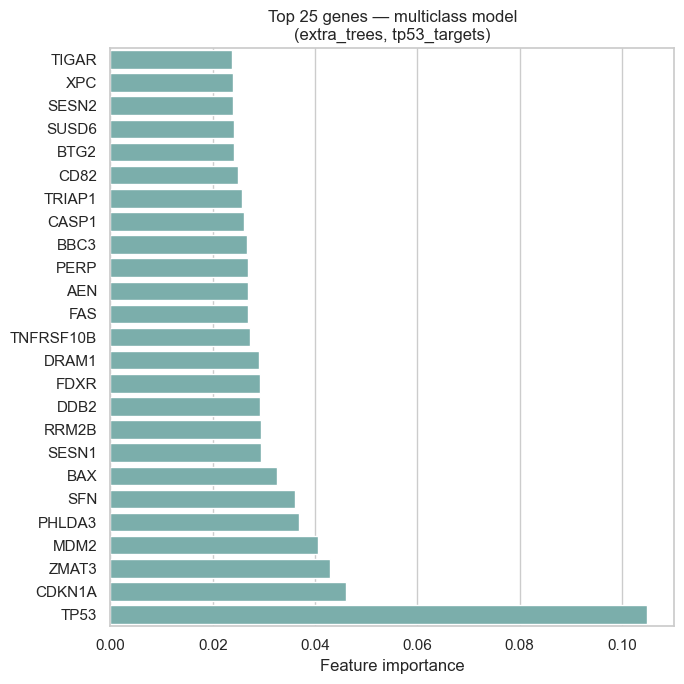

Overlap with TP53 target genes (25): ['AEN', 'BAX', 'BBC3', 'BTG2', 'CASP1', 'CD82', 'CDKN1A', 'DDB2', 'DRAM1', 'FAS', 'FDXR', 'MDM2', 'PERP', 'PHLDA3', 'RRM2B', 'SESN1', 'SESN2', 'SFN', 'SUSD6', 'TIGAR', 'TNFRSF10B', 'TP53', 'TRIAP1', 'XPC', 'ZMAT3']
Overlap with p53 pathway genes  (25): ['AEN', 'BAX', 'BBC3', 'BTG2', 'CASP1', 'CD82', 'CDKN1A', 'DDB2', 'DRAM1', 'FAS', 'FDXR', 'MDM2', 'PERP', 'PHLDA3', 'RRM2B', 'SESN1', 'SESN2', 'SFN', 'SUSD6', 'TIGAR', 'TNFRSF10B', 'TP53', 'TRIAP1', 'XPC', 'ZMAT3']


In [80]:
mc_feat_names = selected_feature_names(best_type_model)
mc_model_obj  = best_type_model.named_steps["model"]

if hasattr(mc_model_obj, "feature_importances_"):
    mc_importance = mc_model_obj.feature_importances_
elif hasattr(mc_model_obj, "coef_"):
    mc_importance = np.abs(mc_model_obj.coef_).mean(axis=0)
else:
    mc_importance = None

if mc_importance is not None and len(mc_feat_names) > 0:
    mc_top = (
        pd.DataFrame({"gene": mc_feat_names, "importance": mc_importance})
        .sort_values("importance", ascending=False)
        .head(25)
    )
    mc_top.to_csv("reports/tables/multiclass_best_model_top_genes.csv", index=False)

    fig, ax = plt.subplots(figsize=(7, 7))
    sns.barplot(data=mc_top.iloc[::-1], x="importance", y="gene", color="#72B7B2", ax=ax)
    ax.set_title(
        f"Top 25 genes — multiclass model\n({best_type_row['model']}, {best_type_row['feature_set']})"
    )
    ax.set_xlabel("Feature importance")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig("reports/figures/multiclass_feature_importance.png", dpi=180)
    plt.show()

    mc_top_set = set(mc_top["gene"])
    tp53_overlap = sorted(mc_top_set & set(TP53_TARGET_GENES))
    pw_overlap   = sorted(mc_top_set & set(P53_PATHWAY_GENES))
    print(f"Overlap with TP53 target genes ({len(tp53_overlap)}): {tp53_overlap}")
    print(f"Overlap with p53 pathway genes  ({len(pw_overlap)}): {pw_overlap}")
else:
    print("Selected multiclass model does not expose feature importances.")

## Step 10: Interpret the Best Binary Model

Interpretation is essential here because we want to know whether the expression features selected by the model make sense in relation to TP53 biology.

For coefficient-based models we inspect absolute coefficients. For tree-based models we inspect feature importance. We then compare important genes with curated TP53 target and p53 pathway genes.

,gene,importance,abs_importance
34,MDM2,-0.752970,0.752970
23,CDKN1A,-0.466410,0.466410
27,DRAM1,-0.407554,0.407554
56,TP53,0.383260,0.383260
3,ATR,0.320089,0.320089
55,TNFRSF10B,-0.306687,0.306687
45,PPM1D,-0.262862,0.262862
43,PLK3,-0.256960,0.256960
5,BAX,-0.244787,0.244787
44,PMAIP1,0.234861,0.234861


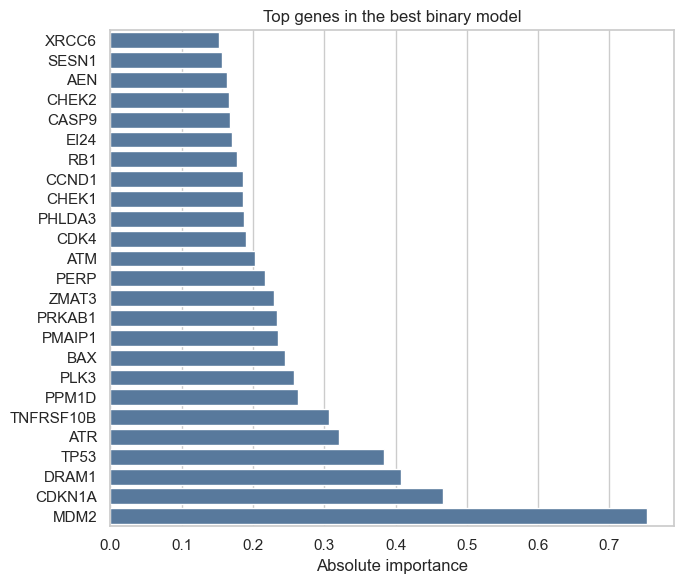

In [81]:
feature_names = selected_feature_names(best_binary_model)
model = best_binary_model.named_steps["model"]

if hasattr(model, "coef_"):
    importance_values = np.ravel(model.coef_)
elif hasattr(model, "feature_importances_"):
    importance_values = model.feature_importances_
else:
    importance_values = None

if importance_values is not None:
    top_model_genes = (
        pd.DataFrame({"gene": feature_names, "importance": importance_values, "abs_importance": np.abs(importance_values)})
        .sort_values("abs_importance", ascending=False)
        .head(100)
    )
    top_model_genes.to_csv("reports/tables/binary_best_model_top_genes.csv", index=False)
    display(top_model_genes.head(20))

    plt.figure(figsize=(7, 6))
    sns.barplot(data=top_model_genes.head(25).iloc[::-1], x="abs_importance", y="gene", color="#4C78A8")
    plt.title("Top genes in the best binary model")
    plt.xlabel("Absolute importance")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig("reports/figures/top_coefficients.png", dpi=180)
    plt.show()
else:
    top_model_genes = pd.DataFrame(columns=["gene", "importance", "abs_importance"])
    print("The selected model does not expose direct feature importance.")

## Step 11: Differential Expression Between TP53 Mutant and WT Samples

In [82]:
labels_indexed = labels.set_index("sample_id")
y_for_de = labels_indexed.loc[X.index, "tp53_mutant"]
mutant_expression = X.loc[y_for_de == 1]
wt_expression = X.loc[y_for_de == 0]

de_rows = []
for gene in X.columns:
    mut_values = mutant_expression[gene]
    wt_values = wt_expression[gene]
    stat = ttest_ind(mut_values, wt_values, equal_var=False, nan_policy="omit")
    de_rows.append(
        {
            "gene": gene,
            "mean_mutant": mut_values.mean(),
            "mean_wt": wt_values.mean(),
            "difference_mutant_minus_wt": mut_values.mean() - wt_values.mean(),
            "p_value": stat.pvalue,
        }
    )

de_table = pd.DataFrame(de_rows)
# Benjamini-Hochberg FDR with step-down enforcement
_p_arr = de_table["p_value"].to_numpy()
_n_de  = len(_p_arr)
_idx   = np.argsort(_p_arr)
_ranks = np.empty(_n_de); _ranks[_idx] = np.arange(1, _n_de + 1)
_fdr   = np.minimum(1.0, _p_arr * _n_de / _ranks)
# step-down: ensure monotonicity
for _ii in range(_n_de - 2, -1, -1):
    _fdr[_idx[_ii]] = min(_fdr[_idx[_ii]], _fdr[_idx[_ii + 1]])
de_table["fdr_bh"] = _fdr
de_table = de_table.sort_values(["fdr_bh", "p_value"])
de_table.to_csv("reports/tables/differential_expression_tp53_mutant_vs_wt.csv", index=False)
de_table.head(20)

,gene,mean_mutant,mean_wt,difference_mutant_minus_wt,p_value,fdr_bh
6281,EDA2R,0.369827,2.163987,-1.794160,3.925008e-131,7.541902e-127
15158,RPS27L,6.404370,7.578244,-1.173874,1.666730e-113,1.601310e-109
5487,CDKN1A,4.700432,6.641905,-1.941473,3.580774e-107,2.293486e-103
6996,MDM2,4.711485,6.031187,-1.319702,9.551311e-98,4.588211e-94
13044,ZMAT3,2.701493,3.906226,-1.204732,8.649890e-97,3.324153e-93
1703,BAX,6.600468,7.253759,-0.653291,5.261418e-67,1.684969e-63
634,RRM2B,3.959146,4.790120,-0.830974,5.681072e-65,1.559454e-61
1484,SESN1,2.827146,3.695974,-0.868828,1.653752e-63,3.972107e-60
6796,DDB2,4.472230,5.182435,-0.710205,2.359904e-52,5.038396e-49
10695,SPATA18,0.354450,1.204454,-0.850004,2.699473e-52,5.187037e-49


### Step 11b: Volcano Plot

The volcano plot maps all ~19 000 genes simultaneously: x-axis = mean expression
difference (Mutant − WT, log₂TPM units), y-axis = −log₁₀(FDR-corrected p-value).
Vertical dashed lines mark the |0.5| fold-change threshold; the horizontal dashed line
marks FDR = 0.05.  Known TP53 target genes are highlighted in red and labelled.

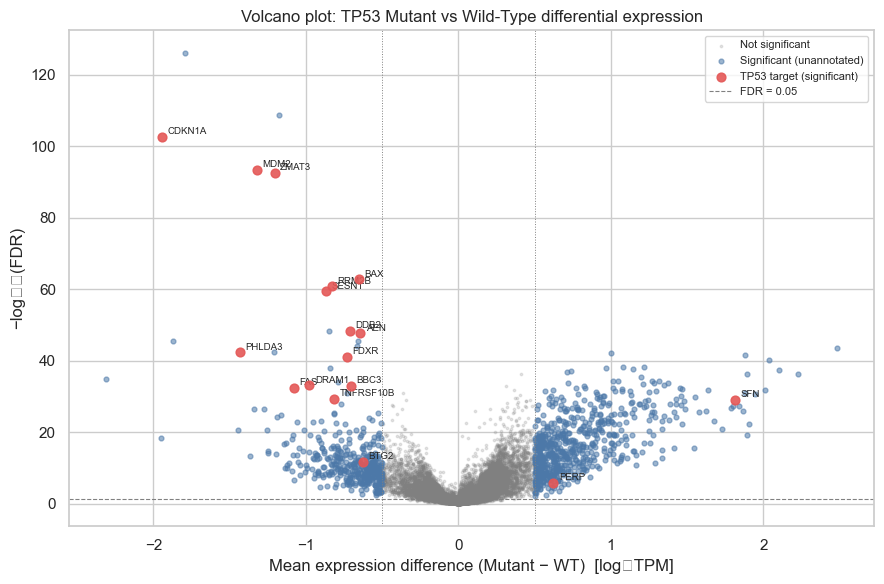

Significant DE genes (FDR < 0.05, |diff| > 0.5) : 1016
  of which are known TP53 target genes           : 17
  of which are p53 pathway genes                 : 18


In [83]:
de_plot = de_table.copy()
de_plot["neg_log10_fdr"] = -np.log10(de_plot["fdr_bh"].clip(lower=1e-300))
de_plot["significant"]   = (
    (de_plot["fdr_bh"] < 0.05) & (de_plot["difference_mutant_minus_wt"].abs() > 0.5)
)
de_plot["is_tp53_target"] = de_plot["gene"].isin(TP53_TARGET_GENES)
de_plot["is_p53_pathway"] = de_plot["gene"].isin(P53_PATHWAY_GENES)

fig, ax = plt.subplots(figsize=(9, 6))

ns = ~de_plot["significant"]
ax.scatter(de_plot.loc[ns, "difference_mutant_minus_wt"],
           de_plot.loc[ns, "neg_log10_fdr"],
           s=3, alpha=0.2, color="grey", label="Not significant", rasterized=True)

sig_other = de_plot["significant"] & ~de_plot["is_tp53_target"]
ax.scatter(de_plot.loc[sig_other, "difference_mutant_minus_wt"],
           de_plot.loc[sig_other, "neg_log10_fdr"],
           s=12, alpha=0.55, color="#4C78A8", label="Significant (unannotated)")

sig_tp = de_plot["significant"] & de_plot["is_tp53_target"]
ax.scatter(de_plot.loc[sig_tp, "difference_mutant_minus_wt"],
           de_plot.loc[sig_tp, "neg_log10_fdr"],
           s=40, alpha=0.9, color="#E45756", zorder=5, label="TP53 target (significant)")

for _, row in de_plot[de_plot["significant"] & de_plot["is_tp53_target"]].head(20).iterrows():
    ax.annotate(row["gene"],
                (row["difference_mutant_minus_wt"], row["neg_log10_fdr"]),
                fontsize=7, xytext=(4, 2), textcoords="offset points")

ax.axhline(-np.log10(0.05), color="grey", linestyle="--", linewidth=0.8, label="FDR = 0.05")
ax.axvline(-0.5, color="grey", linestyle=":", linewidth=0.7)
ax.axvline( 0.5, color="grey", linestyle=":", linewidth=0.7)
ax.set_xlabel("Mean expression difference (Mutant − WT)  [log₂TPM]")
ax.set_ylabel("−log₁₀(FDR)")
ax.set_title("Volcano plot: TP53 Mutant vs Wild-Type differential expression")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig("reports/figures/volcano_differential_expression.png", dpi=180)
plt.show()

sig = de_plot[de_plot["significant"]]
print(f"Significant DE genes (FDR < 0.05, |diff| > 0.5) : {len(sig)}")
print(f"  of which are known TP53 target genes           : {sig['is_tp53_target'].sum()}")
print(f"  of which are p53 pathway genes                 : {sig['is_p53_pathway'].sum()}")

## Step 12: Biological Overlap Summary

Now we connect the statistical results back to biology. A strong project result is not only high AUC; it is high AUC supported by genes that make sense for TP53 transcriptional activity.

In [84]:
top_n = 100
top_de_genes = set(de_table.head(top_n)["gene"])
top_model_gene_set = set(top_model_genes.head(top_n)["gene"])

overlap_summary = pd.DataFrame(
    [
        {
            "comparison": "Top DE genes vs TP53 targets",
            "overlap_count": len(top_de_genes & set(TP53_TARGET_GENES)),
            "genes": ";".join(sorted(top_de_genes & set(TP53_TARGET_GENES))),
        },
        {
            "comparison": "Top DE genes vs p53 pathway",
            "overlap_count": len(top_de_genes & set(P53_PATHWAY_GENES)),
            "genes": ";".join(sorted(top_de_genes & set(P53_PATHWAY_GENES))),
        },
        {
            "comparison": "Top model genes vs TP53 targets",
            "overlap_count": len(top_model_gene_set & set(TP53_TARGET_GENES)),
            "genes": ";".join(sorted(top_model_gene_set & set(TP53_TARGET_GENES))),
        },
        {
            "comparison": "Top model genes vs p53 pathway",
            "overlap_count": len(top_model_gene_set & set(P53_PATHWAY_GENES)),
            "genes": ";".join(sorted(top_model_gene_set & set(P53_PATHWAY_GENES))),
        },
    ]
)
overlap_summary.to_csv("reports/tables/biological_overlap_summary.csv", index=False)
overlap_summary

,comparison,overlap_count,genes
0,Top DE genes vs TP53 targets,16,AEN;BAX;BBC3;CDKN1A;DDB2;DRAM1;FAS;FDXR;MDM2;PHLDA3;RRM2B;SESN1;SFN;TNFRSF10B;TRIAP1;ZMAT3
1,Top DE genes vs p53 pathway,16,AEN;BAX;BBC3;CDKN1A;DDB2;DRAM1;FAS;FDXR;MDM2;PHLDA3;RRM2B;SESN1;SFN;TNFRSF10B;TRIAP1;ZMAT3
2,Top model genes vs TP53 targets,33,AEN;APAF1;BAX;BBC3;BTG2;CASP1;CD82;CDKN1A;DDB2;DRAM1;EI24;FAS;FDXR;GADD45A;MDM2;PANK1;PERP;PHLDA3;PLK3;PMAIP1;PPM1D;...
3,Top model genes vs p53 pathway,62,AEN;APAF1;ATM;ATR;BAK1;BAX;BBC3;BCL2;BCL2L1;BID;BRCA1;BRCA2;BTG2;CASP1;CASP3;CASP8;CASP9;CCND1;CCNE1;CD82;CDK2;CDK4;...


### Step 12b: Formal Biological Enrichment Testing

Reporting gene-set overlap counts is not sufficient without a significance test.
We apply a one-sided **Fisher's exact test** (over-representation) for each combination
of query gene list and biological gene set, using the full post-preprocessing expression
matrix as the gene universe.  P-values are corrected with Benjamini–Hochberg FDR.

> **Important — circularity note.**  Enrichment of *top model genes* for p53-related
> gene sets is partly expected whenever the model was trained on p53-focused feature
> sets (e.g. `p53_pathway`, `tp53_targets`).  Enrichment of *differentially expressed
> genes* is a less circular validation because DE genes are selected from the full
> expression universe using only the mutation labels, independent of the model's feature
> input.  Results are therefore shown in two separate tables; the DE-gene enrichment
> carries stronger independent biological evidence.

In [85]:
from scipy.stats import fisher_exact
from tp53_ml.genes import APOPTOSIS_GENES, DNA_REPAIR_GENES, CELL_CYCLE_GENES

_ENRICH_SETS = {
    "TP53 target genes": set(TP53_TARGET_GENES),
    "p53 pathway genes": set(P53_PATHWAY_GENES),
    "Apoptosis genes":   set(APOPTOSIS_GENES),
    "DNA repair genes":  set(DNA_REPAIR_GENES),
    "Cell cycle genes":  set(CELL_CYCLE_GENES),
}
_universe = set(X.columns)
_N        = len(_universe)

def _fisher_enrich(query, gene_set, universe):
    q  = set(query)   & universe
    gs = set(gene_set) & universe
    N  = len(universe)
    k  = len(q & gs)
    K, n = len(gs), len(q)
    tab = [[k, K-k], [n-k, N-n-K+k]]
    _, p = fisher_exact(tab, alternative="greater")
    odds = (k * max(N-n-K+k, 0)) / max((K-k)*(n-k), 1)
    return {"overlap":k,"gene_set_size":K,"query_size":n,
            "universe_size":N,"odds_ratio":round(odds,3),"p_value":p}

def _bh(pvals):
    n = len(pvals); idx = np.argsort(pvals)
    ranks = np.empty(n); ranks[idx] = np.arange(1, n+1)
    fdr = np.minimum(1.0, np.array(pvals)*n/ranks)
    for i in range(n-2,-1,-1):
        fdr[idx[i]] = min(fdr[idx[i]], fdr[idx[i+1]])
    return fdr

_top_model_g = set(top_model_genes.head(100)["gene"]) if len(top_model_genes)>0 else set()
_top_de_g    = set(de_table.head(100)["gene"])

_enrich_rows = []
for _gs_name, _gs in _ENRICH_SETS.items():
    _enrich_rows.append({"query":"Top-100 model genes","gene_set":_gs_name,
                         **_fisher_enrich(_top_model_g, _gs, _universe)})
    _enrich_rows.append({"query":"Top-100 DE genes",   "gene_set":_gs_name,
                         **_fisher_enrich(_top_de_g,   _gs, _universe)})

enrich_df = pd.DataFrame(_enrich_rows)
for _q, _grp in enrich_df.groupby("query").groups.items():
    enrich_df.loc[_grp,"fdr"] = _bh(enrich_df.loc[_grp,"p_value"].values)
enrich_df["significant"] = enrich_df["fdr"] < 0.05
enrich_df = enrich_df.sort_values(["query","p_value"])
enrich_df.to_csv("reports/tables/biological_enrichment_testing.csv", index=False)

_enrich_cols = ["gene_set","overlap","gene_set_size","odds_ratio","p_value","fdr","significant"]
_enrich_fmt  = {"odds_ratio":2,"p_value":4,"fdr":4}

_model_enrich = enrich_df[enrich_df["query"]=="Top-100 model genes"].copy()
_de_enrich    = enrich_df[enrich_df["query"]=="Top-100 DE genes"].copy()
_model_enrich.to_csv("reports/tables/enrichment_model_genes.csv", index=False)
_de_enrich.to_csv("reports/tables/enrichment_de_genes.csv", index=False)

print("\n--- Enrichment: Top-100 model genes ---")
display(_model_enrich[_enrich_cols].round(_enrich_fmt))

print("\n--- Enrichment: Top-100 differentially expressed genes (less circular) ---")
display(_de_enrich[_enrich_cols].round(_enrich_fmt))


--- Enrichment: Top-100 model genes ---


,gene_set,overlap,gene_set_size,odds_ratio,p_value,fdr,significant
2,p53 pathway genes,62,62,1187486.00,0.0,0.0,True
0,TP53 target genes,33,33,632049.00,0.0,0.0,True
4,Apoptosis genes,21,31,980.50,0.0,0.0,True
6,DNA repair genes,19,35,528.49,0.0,0.0,True
8,Cell cycle genes,14,35,265.72,0.0,0.0,True



--- Enrichment: Top-100 differentially expressed genes (less circular) ---


,gene_set,overlap,gene_set_size,odds_ratio,p_value,fdr,significant
1,TP53 target genes,16,33,213.98,0.0000,0.0000,True
3,p53 pathway genes,16,62,78.96,0.0000,0.0000,True
5,Apoptosis genes,8,31,72.18,0.0000,0.0000,True
7,DNA repair genes,3,35,18.44,0.0008,0.0010,True
9,Cell cycle genes,2,35,11.80,0.0143,0.0143,True


### Step 12c: Expression Directionality of Canonical p53 Target Genes

Wild-type p53 is a transcriptional activator; its canonical targets (CDKN1A, MDM2,
BAX, etc.) should therefore be **lower** in TP53-mutant samples where p53 activity is
reduced.  We tabulate mean expression per group, direction of change, and statistical
significance for the most well-characterised p53 target genes.

In [86]:
from tp53_ml.genes import CANONICAL_P53_TARGETS_INFO

_de_sub = de_table.set_index("gene")

if len(top_model_genes) > 0:
    _imp_sub = top_model_genes.set_index("gene")
    _imp_col = (_imp_sub["abs_importance"] if "abs_importance" in _imp_sub.columns
                else _imp_sub.get("importance", pd.Series(dtype=float)))
else:
    _imp_col = pd.Series(dtype=float)

_dir_rows = []
for _gene, _role in CANONICAL_P53_TARGETS_INFO.items():
    if _gene not in _de_sub.index:
        continue
    _r = _de_sub.loc[_gene]
    _dir_rows.append({
        "gene":             _gene,
        "known_p53_role":   _role,
        "mean_mutant":      round(_r["mean_mutant"], 4),
        "mean_wt":          round(_r["mean_wt"], 4),
        "difference":       round(_r["difference_mutant_minus_wt"], 4),
        "direction":        "lower in mutant" if _r["difference_mutant_minus_wt"]<0
                            else "higher in mutant",
        "fdr":              round(float(_r["fdr_bh"]), 10),
        "model_importance": round(float(_imp_col.get(_gene, float("nan"))), 4),
    })

directionality_df = (
    pd.DataFrame(_dir_rows)
    .sort_values("difference")
    .reset_index(drop=True)
)
directionality_df.to_csv("reports/tables/p53_target_directionality.csv", index=False)
display(directionality_df)

_n_lo = (directionality_df["difference"] < 0).sum()
_n_hi = (directionality_df["difference"] > 0).sum()
print(f"\n{_n_lo}/{len(directionality_df)} canonical p53 targets are lower in TP53-mutant samples.")
print(f"{_n_hi}/{len(directionality_df)} are higher in TP53-mutant samples.")
print("Predominantly lower expression is consistent with reduced wild-type p53 "
      "transcriptional activity.  Some targets may be higher due to gain-of-function "
      "or compensatory effects of mutant p53.")

,gene,known_p53_role,mean_mutant,mean_wt,difference,direction,fdr,model_importance
0,CDKN1A,cell cycle arrest (p21),4.7004,6.6419,-1.9415,lower in mutant,0.000000,0.4664
1,MDM2,p53 negative regulator,4.7115,6.0312,-1.3197,lower in mutant,0.000000,0.7530
2,ZMAT3,mRNA stability / apoptosis,2.7015,3.9062,-1.2047,lower in mutant,0.000000,0.2299
3,FAS,death receptor / apoptosis,3.1685,4.2467,-1.0782,lower in mutant,0.000000,0.1140
4,SESN1,antioxidant / mTOR regulation,2.8271,3.6960,-0.8688,lower in mutant,0.000000,0.1560
5,RRM2B,nucleotide synthesis / DNA repair,3.9591,4.7901,-0.8310,lower in mutant,0.000000,0.1115
6,TNFRSF10B,death receptor (TRAIL-R2),5.1164,5.9301,-0.8136,lower in mutant,0.000000,0.3067
7,FDXR,mitochondrial electron transport,3.2866,4.0167,-0.7301,lower in mutant,0.000000,0.0248
8,DDB2,nucleotide excision repair,4.4722,5.1824,-0.7102,lower in mutant,0.000000,0.1246
9,BBC3,pro-apoptotic (PUMA),2.8645,3.5716,-0.7071,lower in mutant,0.000000,0.0324



14/16 canonical p53 targets are lower in TP53-mutant samples.
2/16 are higher in TP53-mutant samples.
Predominantly lower expression is consistent with reduced wild-type p53 transcriptional activity.  Some targets may be higher due to gain-of-function or compensatory effects of mutant p53.


## Step 13: Final Discussion and Conclusions

### Conclusions

**Binary classification.**  In CCLE cell lines, TP53 mutation status is strongly
predictable from gene expression profiles, particularly using p53 pathway genes
(ROC-AUC > 0.90 on the held-out test set; see Step 8 for bootstrap 95 % CIs).

**Beyond lineage confounding.**  The expression-based model substantially outperforms
the lineage-only baseline (Step 8d), indicating that the predictive signal is not
explained solely by cancer-type composition.  Per-lineage analysis (Step 8c) further
confirms that predictive signal is consistent within individual lineages.

**TP53-expression sensitivity.**  Sensitivity analysis (Step 8e) tests whether
removing TP53 from the feature set preserves performance.  If performance remains
high after exclusion, the model captures *downstream pathway dysregulation* rather than
a single-gene effect, providing a stronger biological interpretation.

**Mutation-type classification.**  The multi-class task (WT, Hotspot Missense,
Other Missense, Truncating, Other) produces lower macro F1 and balanced accuracy
than the binary task.  This is expected: mutation consequence does not map cleanly to
distinct expression states because functional effects depend on allele-specific
properties, zygosity, copy number, tissue context, and co-occurring alterations.
Macro F1 and balanced accuracy — not accuracy — are the reported primary metrics.

**Biological plausibility.**  Formal enrichment tests (Step 12b, Fisher's exact with
BH-FDR) confirm significant overlap between model-selected or differentially expressed
genes and known p53-related gene sets.  The directionality analysis (Step 12c) shows
that canonical p53 transcriptional targets are predominantly lower in TP53-mutant
samples, consistent with reduced wild-type p53 transactivation activity.

**Overall.**  The binary classification results show that TP53 mutation status is
strongly predictable from gene expression profiles in CCLE/DepMap cell lines.  The best
expression-based models substantially outperform simple baselines, including a
lineage-only baseline, indicating that the signal is not explained solely by
cancer-lineage composition.  If sensitivity analysis confirms that performance is
preserved after removing TP53 expression, this supports a broader downstream p53-
pathway signature.  Formal enrichment and directionality analyses show that canonical
p53-related genes are significantly associated with TP53 mutation status.  In contrast,
mutation-type classification is more difficult and should be interpreted as exploratory.
Overall, the project supports a TP53-associated transcriptional signature in CCLE cell
lines, but external validation is required before extending the claim to patient tumors.

---

### Explicit Limitations

1. **Cell lines ≠ patient tumors.**  CCLE cell lines differ from primary tumors in
   growth conditions, clonal evolution, absence of tumour microenvironment, and
   epigenetic drift.
2. **Pan-cancer lineage confounding.**  Even after controlling for lineage with the
   baseline comparison, residual tissue-specific expression differences may inflate
   predictive performance.
3. **Noisy mutation labels.**  TP53 mutation calls depend on sequencing depth, variant
   callers, and filtering thresholds.  Samples near the VAF calling threshold may be
   mislabelled.
4. **Functional effect ≠ mutation type.**  Variant classification (missense, nonsense,
   etc.) is a DNA-level annotation.  Whether a mutation is a loss-of-function,
   dominant-negative, or gain-of-function event depends on the specific amino acid
   change, protein domain context, and cellular background.
5. **Expression as indirect proxy.**  RNA-seq measures transcript abundance, not p53
   protein activity, post-translational modifications, or nuclear localisation.
6. **Context dependence.**  TP53 target gene expression is modulated by many factors
   beyond TP53 status (other transcription factors, chromatin state, growth conditions).
7. **No external validation.**  All results are internal to CCLE.  A TCGA cohort as
   an independent test set is the most important future improvement.

---

### External Validation — Not Performed

External validation on an independent patient cohort (e.g. TCGA) was outside the scope
of the current submission due to data harmonisation requirements (matching gene
identifiers, normalisation strategy, and mutation call pipelines across platforms).

This remains the **single most important extension** of this work:

- Cross-platform batch effects and differences in tumour microenvironment must be
  addressed before a CCLE-trained model can be fairly evaluated on patient data.
- Conclusions are therefore strictly limited to CCLE/DepMap cell lines.

In [87]:
summary = {
    "samples":                   X.shape[0],
    "genes":                     X.shape[1],
    "binary_best_feature_set":   best_feature_set,
    "binary_best_model":         best_model_name,
    "binary_cv_roc_auc":         float(binary_cv.iloc[0]["roc_auc_mean"]),
    "binary_cv_roc_auc_std":     float(binary_cv.iloc[0]["roc_auc_std"]),
    "binary_test_roc_auc":       float(binary_test.loc[0, "roc_auc"]),
    "binary_test_roc_auc_ci_lo": float(ci_auc[0]),
    "binary_test_roc_auc_ci_hi": float(ci_auc[1]),
    "binary_test_pr_auc":        float(binary_test.loc[0, "pr_auc"]),
    "binary_test_f1":            float(binary_test.loc[0, "f1"]),
    "binary_test_f1_ci_lo":      float(ci_f1[0]),
    "binary_test_f1_ci_hi":      float(ci_f1[1]),
    "multiclass_best_feature_set": best_type_row["feature_set"],
    "multiclass_best_model":       best_type_row["model"],
    "multiclass_test_macro_f1":    float(multiclass_test.loc[0, "macro_f1"]),
}
pd.Series(summary).to_frame("project_summary")

,project_summary
samples,1719
genes,19215
binary_best_feature_set,p53_pathway
binary_best_model,elastic_net_logistic
binary_cv_roc_auc,0.909858
binary_cv_roc_auc_std,0.017326
binary_test_roc_auc,0.907099
binary_test_roc_auc_ci_lo,0.865296
binary_test_roc_auc_ci_hi,0.94019
binary_test_pr_auc,0.926426
